In [2]:
import numpy as np
import pandas as pd



import matplotlib.pyplot as plt


import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report

##### Load_datasets

In [3]:
data=pd.read_csv("IMDB Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'[^a-z\s]', '', text)         # remove punctuation/numbers
    text = ' '.join([word for word in text.split() if word not in stop_words])  # remove stopwords
    return text

data['cleaned_review'] = data['review'].apply(preprocess_text)
print(data.head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ajeem\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


                                              review sentiment  \
0  One of the other reviewers has mentioned that ...  positive   
1  A wonderful little production. <br /><br />The...  positive   
2  I thought this was a wonderful way to spend ti...  positive   
3  Basically there's a family where a little boy ...  negative   
4  Petter Mattei's "Love in the Time of Money" is...  positive   

                                      cleaned_review  
0  one reviewers mentioned watching oz episode yo...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically theres family little boy jake thinks...  
4  petter matteis love time money visually stunni...  


In [5]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['cleaned_review'])

y = data['sentiment'].map({'positive': 1, 'negative': 0})  # encode target


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.889


In [9]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.8830248129184718


In [10]:
print("Recall:", recall_score(y_test, y_pred))


Recall: 0.8968


In [11]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



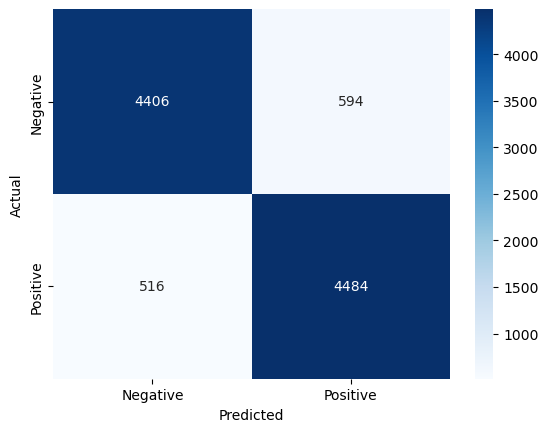

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()